## DAPO

In [43]:
import torch
from matplotlib import pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "font.size": 12,      
    "axes.titlesize": 13, 
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.frameon": False,
})

mpl.rcParams.update({
    "font.family": "STIXGeneral",   
    "mathtext.fontset": "stix",     
})

# loading the dataset entropy gradient-true and gradient-logp
entropy             = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-dapo/100_entropy.pt")
gradient_true       = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-dapo/100_true_gradient.pt")
gradient_logp       = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-dapo/100_logp_gradient.pt")

mask_item           = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-dapo/100_mask.pt")
adv_item            = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-dapo/100_adv.pt")
prefix_item         = np.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-dapo/100_prefix.npy")

/tmp/ipykernel_3770294/4106140665.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  entropy             = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Q

In [44]:
all_dict={}

for k1 in range(len(mask_item)): 
    for k2 in range(len(mask_item[k1])): 

        prefix = prefix_item[k1][k2] 
        mask   = mask_item[k1][k2].to("cpu")

        padded = torch.cat([torch.tensor([False]), mask, torch.tensor([False])])
        changes = padded[1:] != padded[:-1]
        change_idx = torch.nonzero(changes).flatten()

        True_start_id =  change_idx[0::2].item()      
        True_end_id   = (change_idx[1::2] - 1).item() 

        gradient_now_true       = torch.tensor(gradient_true[k1][k2][True_start_id: True_end_id+1]).tolist()
        gradient_now_logp       = torch.tensor(gradient_logp[k1][k2][True_start_id: True_end_id+1]).tolist()
        entropy_now             = torch.tensor(entropy[k1][k2][True_start_id: True_end_id+1]).tolist()
        adv                     = torch.tensor(adv_item[k1][k2]).tolist()

        if(prefix not in all_dict):
            all_dict[prefix]=[[gradient_now_true],[gradient_now_logp],[entropy_now],[adv]]
        else:
            all_dict[prefix][0].append(gradient_now_true)
            all_dict[prefix][1].append(gradient_now_logp)
            all_dict[prefix][2].append(entropy_now)
            all_dict[prefix][3].append(adv)

/tmp/ipykernel_3770294/4272768998.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  entropy_now             = torch.tensor(entropy[k1][k2][True_start_id: True_end_id+1]).tolist()
/tmp/ipykernel_3770294/4272768998.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adv                     = torch.tensor(adv_item[k1][k2]).tolist()


/tmp/ipykernel_3770294/1866104564.py:19: RuntimeWarning: divide by zero encountered in log
  log_entropy   =        [np.log(item) for item in entropy_now_group[k]]
/tmp/ipykernel_3770294/1866104564.py:19: RuntimeWarning: invalid value encountered in log
  log_entropy   =        [np.log(item) for item in entropy_now_group[k]]


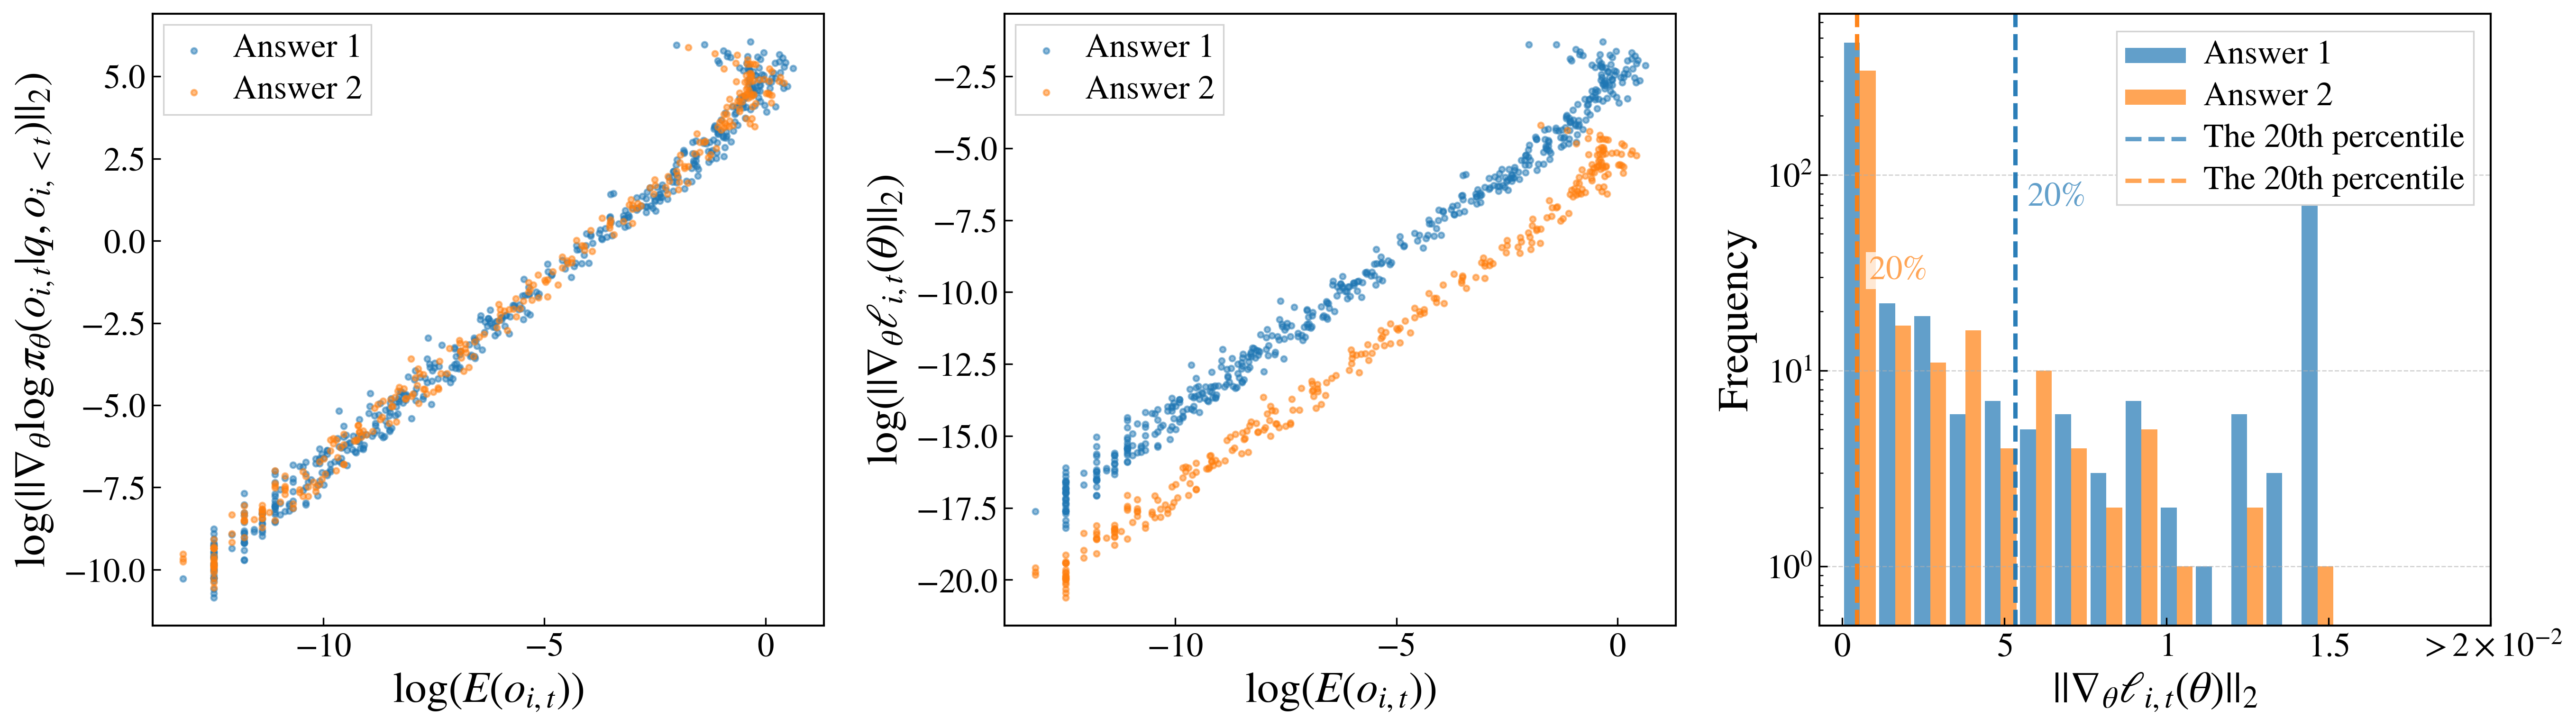

In [86]:
# plot ax1 and ax2 
labelsize = 17
legendsize = 17
titlesize  = 22

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'wspace': 0.05})
ax1, ax2, ax3 = axes


for key in all_dict.keys():
    gradient_true_group = all_dict[key][0]
    gradient_logp_group = all_dict[key][1]
    entropy_now_group   = all_dict[key][2]
    adv_group           = all_dict[key][3]

    for k in range(16):
        log_grad_true =        [np.log(item) for item in gradient_true_group[k]]      
        log_grad_logp =        [np.log(item) for item in gradient_logp_group[k]]      
        log_entropy   =        [np.log(item) for item in entropy_now_group[k]] 
        
        if (k == 0 or k == 1):
            if (k == 0):
                ax1.scatter(log_entropy, log_grad_logp, s=8, alpha=0.5, label='Answer 1')
                ax2.scatter(log_entropy, log_grad_true, s=8, alpha=0.5, label='Answer 1')
                a1_log_true_raw = np.asarray(log_grad_true, dtype=np.float64)
            else:
                ax1.scatter(log_entropy, log_grad_logp, s=8, alpha=0.5, label='Answer 2')
                ax2.scatter(log_entropy, log_grad_true, s=8, alpha=0.5, label='Answer 2')
                a2_log_true_raw = np.asarray(log_grad_true, dtype=np.float64)
            
            ax1.set_xlabel(r'$\log(E(o_{i,t}))$', fontsize=titlesize)
            ax1.set_ylabel(r'$\log(||\nabla_\theta \log \pi_\theta (o_{i,t} |q,o_{i,<t}) ||_{2})$', fontsize=titlesize)

            ax2.set_xlabel(r'$\log(E(o_{i,t}))$', fontsize=titlesize)
            ax2.set_ylabel(r'$\log(||\nabla_\theta \ell_{i,t}(\theta)||_{2})$', fontsize=titlesize)
            
            ax1.tick_params(axis='both', labelsize=labelsize)
            ax2.tick_params(axis='both', labelsize=labelsize)
            
            
            leg1 = ax1.legend(frameon=True, framealpha=1.0, fancybox=False)
            leg1.get_frame().set_edgecolor('lightgray')
            leg1.get_frame().set_linewidth(0.8)

            leg2 = ax2.legend(frameon=True, framealpha=1.0, fancybox=False)
            leg2.get_frame().set_edgecolor('lightgray')   
            leg2.get_frame().set_linewidth(0.8)           
    break      



# plot ax3
def _side_and_align(xq, xmin, xmax, pad_px=10):
    mid = 0.5 * (xmin + xmax)
    if xq <= mid:
        return (+pad_px, 'left')
    else:
        return (-pad_px, 'right')

def _to_np_clean(x):
    x = np.asarray(x, dtype=np.float64)
    return x[np.isfinite(x)]

a1_log = _to_np_clean(a1_log_true_raw)
a2_log = _to_np_clean(a2_log_true_raw)

a1_true = np.exp(a1_log)
a2_true = np.exp(a2_log)

xmin = float(min(a1_true.min(), a2_true.min()))
xmax = float(max(a1_true.max(), a2_true.max()))

bins = np.linspace(a2_true.min(), a2_true.max(), 15)

cnt1, edges = np.histogram(a1_true, bins=bins)
cnt2, _     = np.histogram(a2_true, bins=edges)
cnt1[-1] = cnt1[-1]+656-560

a1_centers = 0.5 * (edges[:-1] + edges[1:])
a2_centers = 0.5 * (xmax + xmin)
width = (edges[1] - edges[0]) * 0.45 if len(edges) > 1 else 0.4

tiny = 0.5 
cnt1_plot = np.where(cnt1 > 0, cnt1, tiny)
cnt2_plot = np.where(cnt2 > 0, cnt2, tiny)

bars1 = ax3.bar(a1_centers - width/2, cnt1_plot, width=width, alpha=0.7, label='Answer 1')
bars2 = ax3.bar(a1_centers + width/2, cnt2_plot, width=width, alpha=0.7, label='Answer 2')

q1_true = float(np.quantile(a1_true, 0.8))
q2_true = float(np.quantile(a2_true, 0.8))

c1 = bars1.patches[0].get_facecolor() if len(bars1.patches) else (0.2,0.4,0.8,0.7)
c2 = bars2.patches[0].get_facecolor() if len(bars2.patches) else (0.8,0.4,0.2,0.7)

ax3.axvline(q1_true, linestyle='--', linewidth=2.2, color=c1, alpha=0.95)
ax3.axvline(q2_true, linestyle='--', linewidth=2.2, color=c2, alpha=0.95)

y_a1_frac = 0.70
y_a2_frac = 0.58

dx1, ha1 = _side_and_align(q1_true, xmin, xmax, pad_px=6)
ax3.annotate(r'$20\%\ $',
             xy=(q1_true, y_a1_frac), xycoords=('data', 'axes fraction'),
             xytext=(dx1, 0), textcoords='offset points',
             ha=ha1, va='center', fontsize=legendsize, color=c1,
             bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
             zorder=10, clip_on=False,
             )

dx2, ha2 = _side_and_align(q2_true, xmin, xmax, pad_px=6)
ax3.annotate(r'$20\%\ $',
             xy=(q2_true, y_a2_frac), xycoords=('data', 'axes fraction'),
             xytext=(dx2, 0), textcoords='offset points',
             ha=ha2, va='center', fontsize=legendsize, color=c2,
             bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
             zorder=10, clip_on=False)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
bar1_color = bars1.patches[0].get_facecolor() if len(bars1.patches) else c1
bar2_color = bars2.patches[0].get_facecolor() if len(bars2.patches) else c2
handles = [
    Patch(facecolor=bar1_color, edgecolor='none', label='Answer 1'),
    Patch(facecolor=bar2_color, edgecolor='none', label='Answer 2'),
    Line2D([0], [0], color=c1, linestyle='--', linewidth=2.2, label='The 20th percentile'),
    Line2D([0], [0], color=c2, linestyle='--', linewidth=2.2, label='The 20th percentile'),
]


custom_ticks  = [0.000, 0.005, 0.010, 0.015, 0.02]
custom_labels = [r'$0$', r'$5$',r'$1$',r'$1.5$',r'$>2' r'\times 10^{-2}$']
ax3.set_yscale('log')
ax3.set_ylim(bottom=tiny)
ax3.set_xlabel(r'$ ||\nabla_\theta \ell_{i,t}(\theta)||_{2} $', fontsize=titlesize)
ax3.set_ylabel(r'$\mathrm{Frequency}$', fontsize=titlesize)
ax3.tick_params(axis='both', labelsize=labelsize)

ax3.set_xticks(custom_ticks)
ax3.set_xticklabels(custom_labels)
ax3.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
leg3 = ax3.legend(handles=handles,
                  loc='best',
                  frameon=True, framealpha=1.0, fancybox=False,
                  handlelength=2.8, borderaxespad=0.8)
leg3.get_frame().set_edgecolor('lightgray')   
leg3.get_frame().set_linewidth(0.8)

leg1.set_draggable(True) 
for txt in leg1.get_texts(): txt.set_fontsize(legendsize)
for txt in leg2.get_texts(): txt.set_fontsize(legendsize)
for txt in leg3.get_texts(): txt.set_fontsize(legendsize)

## GRPO

In [87]:
# loading the dataset entropy gradient-true and gradient-logp
entropy             = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-grpo/100_entropy.pt")
gradient_true       = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-grpo/100_true_gradient.pt")
gradient_logp       = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-grpo/100_logp_gradient.pt")

mask_item           = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-grpo/100_mask.pt")
adv_item            = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-grpo/100_adv.pt")
prefix_item         = np.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen2.5-math-1.5b-grpo/100_prefix.npy")

/tmp/ipykernel_3770294/40754129.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  entropy             = torch.load("/home/zyw/GMTS/GMTS-Framework1/result/gradient_dir/Qwen

In [88]:
all_dict={}

for k1 in range(len(mask_item)): 
    for k2 in range(len(mask_item[k1])): 

        prefix = prefix_item[k1][k2] 
        mask   = mask_item[k1][k2].to("cpu")

        padded = torch.cat([torch.tensor([False]), mask, torch.tensor([False])])
        changes = padded[1:] != padded[:-1]
        change_idx = torch.nonzero(changes).flatten()

        True_start_id =  change_idx[0::2].item()       
        True_end_id   = (change_idx[1::2] - 1).item() 

        gradient_now_true       = torch.tensor(gradient_true[k1][k2][True_start_id: True_end_id+1]).tolist()
        gradient_now_logp       = torch.tensor(gradient_logp[k1][k2][True_start_id: True_end_id+1]).tolist()
        entropy_now             = torch.tensor(entropy[k1][k2][True_start_id: True_end_id+1]).tolist()
        adv                     = torch.tensor(adv_item[k1][k2]).tolist()

        if(prefix not in all_dict):
            all_dict[prefix]=[[gradient_now_true],[gradient_now_logp],[entropy_now],[adv]]
        else:
            all_dict[prefix][0].append(gradient_now_true)
            all_dict[prefix][1].append(gradient_now_logp)
            all_dict[prefix][2].append(entropy_now)
            all_dict[prefix][3].append(adv)

/tmp/ipykernel_3770294/4272768998.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  entropy_now             = torch.tensor(entropy[k1][k2][True_start_id: True_end_id+1]).tolist()
/tmp/ipykernel_3770294/4272768998.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adv                     = torch.tensor(adv_item[k1][k2]).tolist()


/tmp/ipykernel_3770294/3528323353.py:18: RuntimeWarning: divide by zero encountered in log
  log_entropy   =        [np.log(item) for item in entropy_now_group[k]]
/tmp/ipykernel_3770294/3528323353.py:18: RuntimeWarning: invalid value encountered in log
  log_entropy   =        [np.log(item) for item in entropy_now_group[k]]


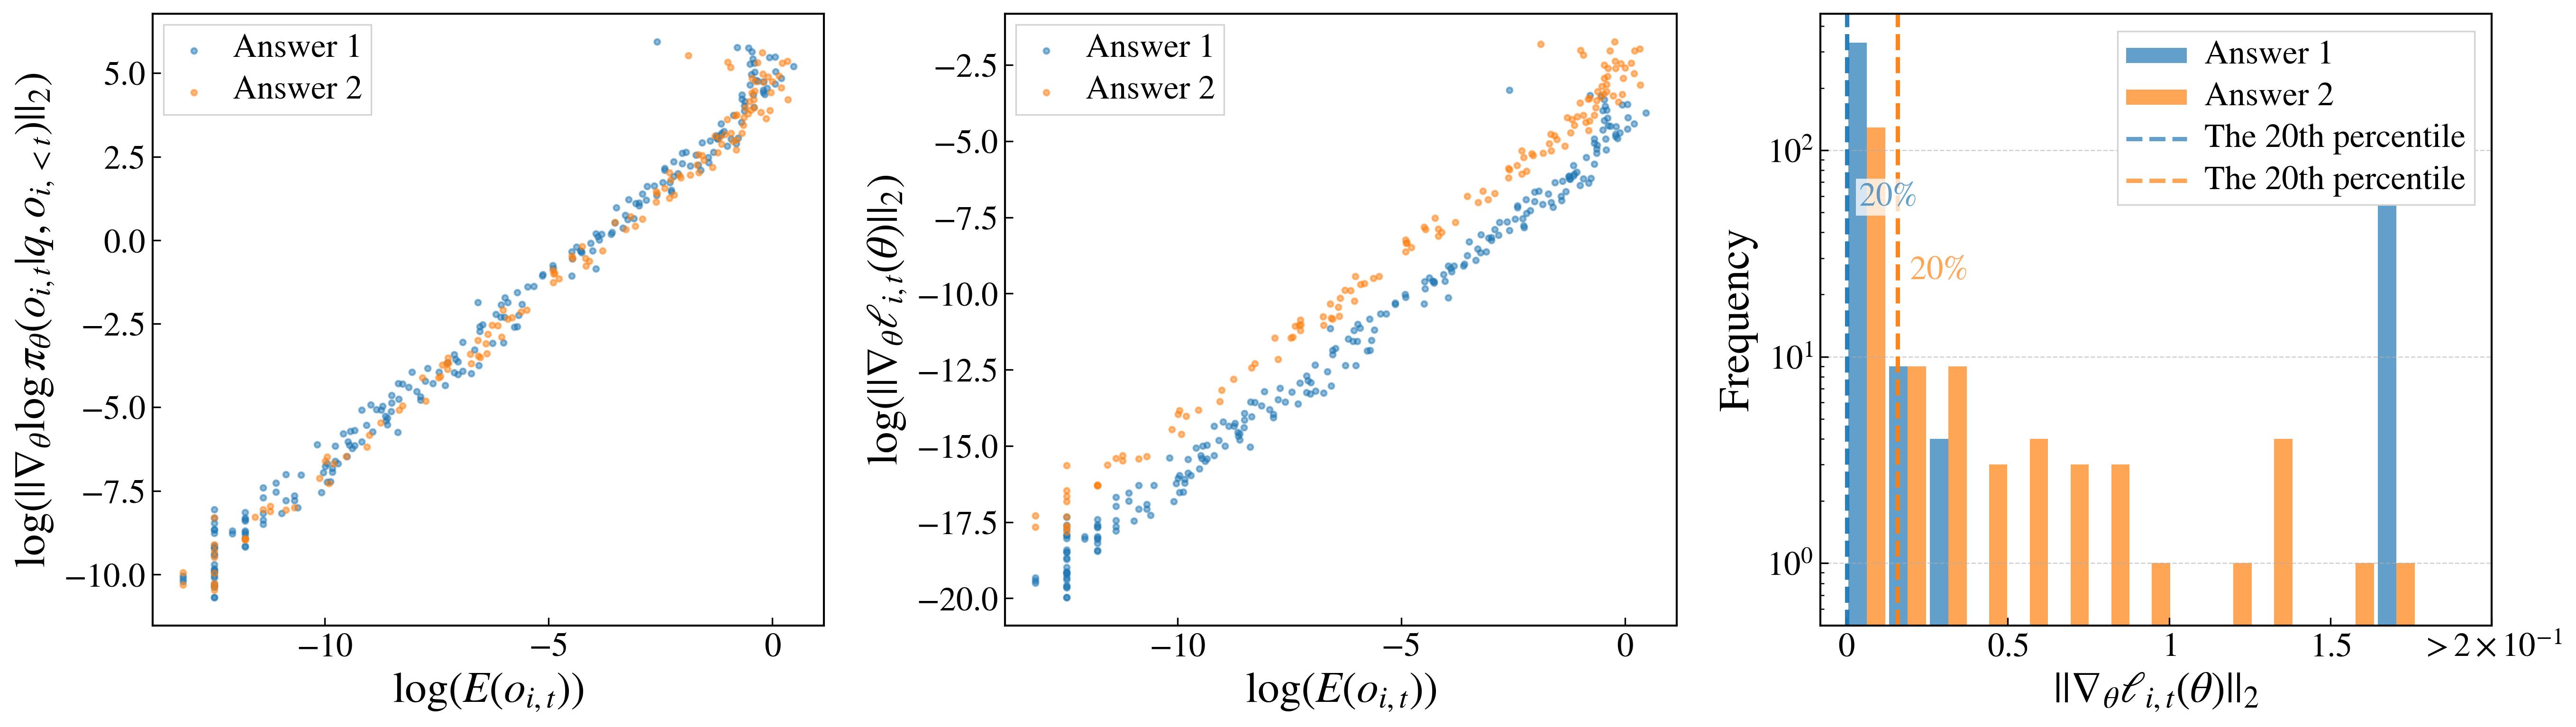

In [104]:
# plot ax1 and ax2 
labelsize = 17
legendsize = 17
titlesize  = 22

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'wspace': 0.05})
ax1, ax2, ax3 = axes

for key in all_dict.keys():
    gradient_true_group = all_dict[key][0]
    gradient_logp_group = all_dict[key][1]
    entropy_now_group   = all_dict[key][2]
    adv_group           = all_dict[key][3]

    for k in range(16):
        log_grad_true =        [np.log(item) for item in gradient_true_group[k]]      
        log_grad_logp =        [np.log(item) for item in gradient_logp_group[k]]      
        log_entropy   =        [np.log(item) for item in entropy_now_group[k]] 
        
        if (k == 0 or k == 8):
            if (k == 0):
                ax1.scatter(log_entropy, log_grad_logp, s=8, alpha=0.5, label='Answer 1')
                ax2.scatter(log_entropy, log_grad_true, s=8, alpha=0.5, label='Answer 1')
                a1_log_true_raw = np.asarray(log_grad_true, dtype=np.float64)
            else:
                ax1.scatter(log_entropy, log_grad_logp, s=8, alpha=0.5, label='Answer 2')
                ax2.scatter(log_entropy, log_grad_true, s=8, alpha=0.5, label='Answer 2')
                a2_log_true_raw = np.asarray(log_grad_true, dtype=np.float64)
            
            ax1.set_xlabel(r'$\log(E(o_{i,t}))$', fontsize=titlesize)
            ax1.set_ylabel(r'$\log(||\nabla_\theta \log \pi_\theta (o_{i,t} |q,o_{i,<t}) ||_{2})$', fontsize=titlesize)

            ax2.set_xlabel(r'$\log(E(o_{i,t}))$', fontsize=titlesize)
            ax2.set_ylabel(r'$\log(||\nabla_\theta \ell_{i,t}(\theta)||_{2})$', fontsize=titlesize)
            
            ax1.tick_params(axis='both', labelsize=labelsize)
            ax2.tick_params(axis='both', labelsize=labelsize)
            
            
            leg1 = ax1.legend(frameon=True, framealpha=1.0, fancybox=False)
            leg1.get_frame().set_edgecolor('lightgray')
            leg1.get_frame().set_linewidth(0.8)

            leg2 = ax2.legend(frameon=True, framealpha=1.0, fancybox=False)
            leg2.get_frame().set_edgecolor('lightgray')   
            leg2.get_frame().set_linewidth(0.8)           
    break      




# plot ax3
def _side_and_align(xq, xmin, xmax, pad_px=10):
    mid = 0.5 * (xmin + xmax)
    if xq <= mid:
        return (+pad_px, 'left')
    else:
        return (-pad_px, 'right')

def _to_np_clean(x):
    x = np.asarray(x, dtype=np.float64)
    return x[np.isfinite(x)]

a1_log = _to_np_clean(a1_log_true_raw)
a2_log = _to_np_clean(a2_log_true_raw)

a1_true = np.exp(a1_log)
a2_true = np.exp(a2_log)

xmin = float(min(a1_true.min(), a2_true.min()))
xmax = float(max(a1_true.max(), a2_true.max()))

bins = np.linspace(a2_true.min(), a2_true.max(), 15)

cnt1, edges = np.histogram(a1_true, bins=bins)
cnt2, _     = np.histogram(a2_true, bins=edges)
cnt1[-1] = cnt1[-1]+440-386

a1_centers = 0.5 * (edges[:-1] + edges[1:])
a2_centers = 0.5 * (xmax + xmin)
width = (edges[1] - edges[0]) * 0.45 if len(edges) > 1 else 0.4

tiny = 0.5 
cnt1_plot = np.where(cnt1 > 0, cnt1, tiny)
cnt2_plot = np.where(cnt2 > 0, cnt2, tiny)

bars1 = ax3.bar(a1_centers - width/2, cnt1_plot, width=width, alpha=0.7, label='Answer 1')
bars2 = ax3.bar(a1_centers + width/2, cnt2_plot, width=width, alpha=0.7, label='Answer 2')

q1_true = float(np.quantile(a1_true, 0.8))
q2_true = float(np.quantile(a2_true, 0.8))

c1 = bars1.patches[0].get_facecolor() if len(bars1.patches) else (0.2,0.4,0.8,0.7)
c2 = bars2.patches[0].get_facecolor() if len(bars2.patches) else (0.8,0.4,0.2,0.7)

ax3.axvline(q1_true, linestyle='--', linewidth=2.2, color=c1, alpha=0.95)
ax3.axvline(q2_true, linestyle='--', linewidth=2.2, color=c2, alpha=0.95)

y_a1_frac = 0.70
y_a2_frac = 0.58

dx1, ha1 = _side_and_align(q1_true, xmin, xmax, pad_px=6)
ax3.annotate(r'$20\%\ $',
             xy=(q1_true, y_a1_frac), xycoords=('data', 'axes fraction'),
             xytext=(dx1, 0), textcoords='offset points',
             ha=ha1, va='center', fontsize=legendsize, color=c1,
             bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
             zorder=10, clip_on=False,
             )

dx2, ha2 = _side_and_align(q2_true, xmin, xmax, pad_px=6)
ax3.annotate(r'$20\%\ $',
             xy=(q2_true, y_a2_frac), xycoords=('data', 'axes fraction'),
             xytext=(dx2, 0), textcoords='offset points',
             ha=ha2, va='center', fontsize=legendsize, color=c2,
             bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
             zorder=10, clip_on=False)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
bar1_color = bars1.patches[0].get_facecolor() if len(bars1.patches) else c1
bar2_color = bars2.patches[0].get_facecolor() if len(bars2.patches) else c2
handles = [
    Patch(facecolor=bar1_color, edgecolor='none', label='Answer 1'),
    Patch(facecolor=bar2_color, edgecolor='none', label='Answer 2'),
    Line2D([0], [0], color=c1, linestyle='--', linewidth=2.2, label='The 20th percentile'),
    Line2D([0], [0], color=c2, linestyle='--', linewidth=2.2, label='The 20th percentile'),
]


custom_ticks  = [0.0, 0.05, 0.1, 0.15, 0.2]
custom_labels = [r'$0$', r'$0.5$',r'$1$',r'$1.5$',r'$>2' r'\times 10^{-1}$']
ax3.set_yscale('log')
ax3.set_ylim(bottom=tiny)
ax3.set_xlabel(r'$ ||\nabla_\theta \ell_{i,t}(\theta)||_{2} $', fontsize=titlesize)
ax3.set_ylabel(r'$\mathrm{Frequency}$', fontsize=titlesize)
ax3.tick_params(axis='both', labelsize=labelsize)

ax3.set_xticks(custom_ticks)
ax3.set_xticklabels(custom_labels)
ax3.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
leg3 = ax3.legend(handles=handles,
                  loc='best',
                  frameon=True, framealpha=1.0, fancybox=False,
                  handlelength=2.8, borderaxespad=0.8)
leg3.get_frame().set_edgecolor('lightgray')   
leg3.get_frame().set_linewidth(0.8)

leg1.set_draggable(True)  
for txt in leg1.get_texts(): txt.set_fontsize(legendsize)
for txt in leg2.get_texts(): txt.set_fontsize(legendsize)
for txt in leg3.get_texts(): txt.set_fontsize(legendsize)